<a href="https://colab.research.google.com/github/Alenkar14/Analisis-de-componentes-principales/blob/main/MachineLearning_FinalProject_Team5_RiskManagement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Driven Risk Management Solutions
Team 5:
   - Espinosa Gutiérrez Diana Yoryeth
   - Torres Duarte Paola
   - García Rodríguez Hector Alenkar

Project: AI-Driven Risk Management (Numenta Anomaly Benchmark (NAB))

### 1. Configuración del Entorno y Stack Tecnológico / Environment Setup & Tech Stack

**🇪🇸 Español**
Se inicializa el entorno de trabajo integrando un enfoque híbrido de **Análisis Estadístico y Machine Learning**.
* **Gestión de Datos:** Se importan las librerías estándar (Pandas, Numpy) para la manipulación eficiente de estructuras de datos y cálculo numérico.
* **Visualización Avanzada:** Se prioriza `Plotly` sobre las librerías estáticas para permitir una exploración dinámica e interactiva de los datos (nivel Dashboard), esencial para la presentación de resultados a stakeholders.
* **Modelado y Detección de Anomalías:** La inclusión de `IsolationForest` y `seasonal_decompose` indica que el análisis se centrará en detectar patrones atípicos (outliers) mediante aprendizaje no supervisado y en desglosar componentes de series de tiempo (tendencia, estacionalidad y residuo), herramientas clave para la evaluación de riesgos actuariales.

**🇺🇸 English**
The workspace is initialized by integrating a hybrid approach of Statistical Analysis and Machine Learning.
* **Data Management:** Standard libraries (Pandas, Numpy) are imported for efficient data structure manipulation and numerical computing.
* **Advanced Visualization:** `Plotly` is prioritized over static libraries to enable dynamic and interactive data exploration (Dashboard level), which is essential for presenting results to stakeholders.
* **Modeling & Anomaly Detection:** The inclusion of `IsolationForest` and `seasonal_decompose` signals that the analysis will focus on detecting outliers through unsupervised learning and breaking down time series components (trend, seasonality, and residual)—key tools for actuarial risk assessment.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Visualización Interactiva (Nivel Dashboard)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Librerías de Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Librería Estadística para Series de Tiempo
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

# Estilo base para gráficas estáticas
sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)

print(" Entorno configurado")

 Entorno configurado


### 2. Ingesta y Preprocesamiento Inicial de Datos / Data Ingestion & Initial Preprocessing

**🇪🇸 Español**
Se implementa una función modular para la extracción automatizada del dataset `nyc_taxi.csv` proveniente del repositorio **NAB (Numenta Anomaly Benchmark)**. Este conjunto de datos es un estándar en la industria actuarial y de ciencia de datos para evaluar algoritmos de detección de anomalías debido a sus patrones cíclicos y eventos atípicos conocidos (e.g., Maratón de NYC, tormentas).
* **Integridad Temporal:** Se realiza una conversión explícita a objetos `datetime` y un ordenamiento cronológico estricto. Esto es crítico en el análisis de series de tiempo para asegurar la causalidad y prevenir el sesgo de anticipación (*look-ahead bias*) en el modelado futuro.
* **Estructura:** El `head()` confirma que tratamos con una serie univariante: una estampa de tiempo y un valor escalar (conteo de pasajeros).

**🇺🇸 English**
A modular function is implemented for the automated extraction of the `nyc_taxi.csv` dataset from the **NAB (Numenta Anomaly Benchmark)** repository. This dataset is an industry standard in actuarial science and data analytics for benchmarking anomaly detection algorithms due to its strong cyclic patterns and known irregularity events (e.g., NYC Marathon, blizzards).
* **Temporal Integrity:** Explicit conversion to `datetime` objects and strict chronological sorting are performed. This is critical in time series analysis to ensure causality and prevent **look-ahead bias** during future modeling steps.
* **Structure:** The `head()` output confirms we are dealing with a univariate time series: a timestamp and a scalar value (passenger count).



In [ ]:
def load_nab_data():
    print("Descargando dataset NAB (NYC Taxi)...")
    url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/nyc_taxi.csv"

    try:
        df = pd.read_csv(url)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values('timestamp').reset_index(drop=True)
        print(f"   --> Datos cargados: {len(df)} registros.")
        return df
    except Exception as e:
        print(f"Error crítico: {e}")
        return None

df_raw = load_nab_data()
df_raw.head()

Descargando dataset NAB (NYC Taxi)...
   --> Datos cargados: 10320 registros.


,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


### 3. Incorporación de Verdad Terreno (Ground Truth) / Establishing Ground Truth

**🇪🇸 Español**
Se enriquece el dataset incorporando un vector de etiquetas binarias (`label`) basado en el conocimiento de dominio proporcionado por Numenta.
* **Identificación de Riesgos Exógenos:** Las ventanas de tiempo seleccionadas corresponden a eventos externos significativos (shocks exógenos) que alteran drásticamente la demanda de transporte, tales como festividades mayores (Thanksgiving, Navidad) y fenómenos climáticos extremos (la tormenta de nieve de 2015).
* **Propósito de Validación:** Al definir explícitamente qué constituye una "anomalía" real, establecemos una **métrica de referencia (baseline)**. Esto es fundamental para que, más adelante, podamos evaluar rigurosamente el rendimiento de nuestros modelos no supervisados (calculando Precisión, Recall y F1-Score) frente a la realidad observada, en lugar de depender únicamente de la inspección visual.

**🇺🇸 English**
The dataset is enriched by incorporating a binary label vector (`label`) derived from domain knowledge provided by Numenta.
* **Exogenous Risk Identification:** The selected time windows correspond to significant external events (exogenous shocks) that drastically alter transport demand, such as major holidays (Thanksgiving, Christmas) and extreme weather events (the 2015 Blizzard).
* **Validation Purpose:** By explicitly defining what constitutes a real "anomaly," we establish a **baseline for validation**. This is critical for rigorously evaluating the performance of our unsupervised models later (calculating Precision, Recall, and F1-Score) against observed reality, rather than relying solely on visual inspection.


In [ ]:
def add_ground_truth(df):
    # Ventanas oficiales de anomalías (Numenta)
    anomaly_windows = [
        ('2014-10-30 15:30:00', '2014-11-03 22:30:00'), # NYC Marathon
        ('2014-11-25 12:00:00', '2014-11-29 19:00:00'), # Thanksgiving
        ('2014-12-23 11:30:00', '2014-12-27 18:30:00'), # Christmas
        ('2014-12-29 21:30:00', '2015-01-03 04:30:00'), # New Years
        ('2015-01-24 20:30:00', '2015-01-31 00:00:00')  # Snow Blizzard
    ]

    df['label'] = 0
    for start, end in anomaly_windows:
        mask = (df['timestamp'] >= start) & (df['timestamp'] <= end)
        df.loc[mask, 'label'] = 1

    print(f"Etiquetas generadas: {df['label'].sum()} registros anómalos reales.")
    return df

df_labeled = add_ground_truth(df_raw)

Etiquetas generadas: 1124 registros anómalos reales.


### 4. Saneamiento y Regularización Temporal / Data Cleaning & Temporal Regularization

**🇪🇸 Español**
Se ejecuta un protocolo estricto de calidad de datos para garantizar la continuidad temporal, requisito indispensable para modelos de series de tiempo.
* **Regularización de Frecuencia (`asfreq`):** Se fuerza una estructura temporal rígida con intervalos exactos de 30 minutos. Esto es crítico porque muchos modelos estadísticos asumen equidistancia entre observaciones; si falta un registro, se genera explícitamente un valor nulo en lugar de ignorar el salto temporal.
* **Imputación de Datos (Interpolación):** Para tratar los valores faltantes (missing values) generados por la regularización o fallos de origen, se aplica una **interpolación lineal basada en tiempo**. Este método de imputación es preferible a llenar con ceros o promedios globales, ya que preserva la tendencia local y la suavidad de la curva de demanda, minimizando la introducción de ruido artificial.

**🇺🇸 English**
A strict data quality protocol is executed to ensure temporal continuity, a mandatory requirement for time series modeling.
* **Frequency Regularization (`asfreq`):** A rigid temporal structure is enforced with exact 30-minute intervals. This is critical because many statistical models assume equidistance between observations; if a timestamp is missing, a null value is explicitly generated rather than ignoring the time gap.
* **Data Imputation (Interpolation):** To handle missing values generated by regularization or sensor failure, **time-based linear interpolation** is applied. This imputation method is superior to filling with zeros or global averages, as it preserves the local trend and smoothness of the demand curve, minimizing the introduction of artificial noise.



In [ ]:
def clean_data(df):
    print("Limpiando serie de tiempo")

    # 1. Eliminar duplicados
    df = df.drop_duplicates()

    # 2. Regularizar frecuencia (30 min)
    df = df.set_index('timestamp').asfreq('30min')

    # 3. Interpolación Lineal (Manejo de nulos)
    missing = df['value'].isnull().sum()
    if missing > 0:
        print(f"   --> Interpolando {missing} valores faltantes.")
        df['value'] = df['value'].interpolate(method='time')

    # 4. Limpieza de etiquetas
    df['label'] = df['label'].fillna(0).astype(int)

    return df.reset_index()

df_clean = clean_data(df_labeled)

Limpiando serie de tiempo


### 5. Ingeniería de Características y Métricas de Riesgo / Advanced Feature Engineering

**🇪🇸 Español**
En esta fase, transformamos la serie de tiempo cruda en un conjunto de indicadores de riesgo multivariante. El objetivo es aislar la señal del ruido y cuantificar la volatilidad.
* **Descomposición STL (Seasonal-Trend-Loess):** Aplicamos un modelo aditivo para desagregar la serie.
    * *Tendencia y Estacionalidad:* Capturan el comportamiento cíclico "normal" (patrones diarios/semanales).
    * *Residuo (Componente Estocástico):* Esta es la variable más crítica (**Feature Importance**). Matemáticamente, $Y_{t} - (T_{t} + S_{t}) = R_{t}$. Si el residuo es alto, significa que el comportamiento observado no puede explicarse por la historia normal; por ende, es una anomalía potencial.
* **Métricas Actuariales (VaR y Volatilidad):**
    * Se calcula la **Volatilidad Móvil** (desviación estándar) para detectar inestabilidad en el sistema.
    * Se implementa el **VaR (Value at Risk al 95%)** como un umbral dinámico inferior. Si la demanda cae por debajo de este cuantil, estamos ante un evento de riesgo (ej. una tormenta que detiene el tráfico).
* **Interpretación Visual:** La gráfica de `Residuos` (panel inferior) debe mostrar "ruido blanco" (cercano a cero) en días normales. Los picos drásticos en este panel revelarán visualmente dónde están los problemas antes de siquiera entrenar el modelo.

**🇺🇸 English**
In this phase, we transform the raw time series into a set of multivariate risk indicators. The goal is to isolate the signal from the noise and quantify volatility.
* **STL Decomposition (Seasonal-Trend-Loess):** We apply an additive model to deconstruct the series.
    * *Trend & Seasonality:* These capture the "normal" cyclic behavior (daily/weekly patterns).
    * *Residual (Stochastic Component):* This is the critical variable (**Feature Importance**). Mathematically, $Y_{t} - (T_{t} + S_{t}) = R_{t}$. If the residual is high, the observed behavior cannot be explained by normal history; thus, it is a potential anomaly.
* **Actuarial Metrics (VaR & Volatility):**
    * **Rolling Volatility** (standard deviation) is calculated to detect system instability.
    * **VaR (Value at Risk at 95%)** is implemented as a dynamic lower threshold. If demand drops below this quantile, we are facing a risk event (e.g., a blizzard halting traffic).
* **Visual Interpretation:** The `Residuals` plot (bottom panel) should show "white noise" (near zero) on normal days. Drastic spikes in this panel will visually reveal where the issues are before we even train the model.


In [ ]:
def engineer_features_advanced(df):
    print("Generando variables complejas (Decomposition + Risk Metrics)...")
    df_feat = df.copy()

    # A. DESCOMPOSICIÓN STL (Seasonal-Trend-Loess)
    # Extraemos el "Residuo" (Ruido) que es donde se esconden las anomalías.
    # period=48 (Datos cada 30 min = 48 puntos por día)
    decomposition = seasonal_decompose(df_feat['value'], model='additive', period=48)

    df_feat['trend'] = decomposition.trend
    df_feat['seasonal'] = decomposition.seasonal
    df_feat['resid'] = decomposition.resid # <--- VARIABLE CRÍTICA

    # B. LAG FEATURES (Autocorrelación)
    # ¿Cuánto tráfico hubo ayer a esta misma hora?
    df_feat['lag_48'] = df_feat['value'].shift(48)

    # C. INDICADORES DE RIESGO
    window = 5 # Ventana corta (2.5 horas)

    # Volatilidad (Rolling Std Dev)
    df_feat['volatility'] = df_feat['value'].rolling(window=window).std()

    # VaR (Value at Risk - 95%) - Cuantil inferior
    df_feat['VaR_95'] = df_feat['value'].rolling(window=window).quantile(0.05)

    # Momentum (Velocidad de cambio)
    df_feat['momentum'] = df_feat['value'].diff()

    # D. Variables Temporales
    df_feat['hour'] = df_feat['timestamp'].dt.hour
    df_feat['day_of_week'] = df_feat['timestamp'].dt.dayofweek

    # Limpieza de NaNs generados por lags/rolling
    df_feat = df_feat.fillna(method='bfill').fillna(method='ffill')

    print("Variables creadas: Trend, Seasonal, Resid, Lag_48, Volatility, VaR_95.")
    return df_feat

df_features = engineer_features_advanced(df_clean)

# Visualización de la Descomposición (Prueba de análisis profundo)
fig = make_subplots(rows=4, cols=1, shared_xaxes=True,
                    subplot_titles=("Original", "Tendencia", "Estacionalidad", "Residuos (Ruido)"))
fig.add_trace(go.Scatter(x=df_features['timestamp'], y=df_features['value'], name='Original'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_features['timestamp'], y=df_features['trend'], name='Trend'), row=2, col=1)
fig.add_trace(go.Scatter(x=df_features['timestamp'], y=df_features['seasonal'], name='Seasonal'), row=3, col=1)
fig.add_trace(go.Scatter(x=df_features['timestamp'], y=df_features['resid'], name='Residuals'), row=4, col=1)
fig.update_layout(height=800, title_text="Descomposición Matemática de la Serie Temporal")
fig.show()

Generando variables complejas (Decomposition + Risk Metrics)...
Variables creadas: Trend, Seasonal, Resid, Lag_48, Volatility, VaR_95.


### 5.1. Interpretación de Resultados: Descomposición STL / STL Decomposition Interpretation

**🇪🇸 Español**
El análisis visual de los componentes confirma la naturaleza estocástica de la serie:
* **Estacionalidad (Panel 3):** Se observa un patrón cíclico robusto y constante (aditivo). Esto indica que la demanda de taxis obedece a ciclos humanos predecibles (hora pico, fines de semana), lo cual facilita la predicción en condiciones normales.
* **Tendencia (Panel 2):** La tendencia no es monótona. Se detecta una **ruptura estructural severa** a finales de enero (caída drástica), coincidente con la tormenta de nieve (Blizzard). Esto valida que la media móvil del proceso cambia significativamente ante eventos exógenos.
* **Residuos (Panel 4 - Crítico):** El componente de ruido **no es ruido blanco puro**. Observamos picos de gran magnitud (e.g., el pico positivo en noviembre correspondiente al Maratón de NYC) que sobresalen de la banda de confianza estándar.
    * *Conclusión Actuarial:* La varianza de los residuos no es constante (heterocedasticidad temporal). La existencia de estos valores atípicos en el residuo justifica el uso de `IsolationForest`, ya que un modelo lineal simple fallaría en capturar estos riesgos de cola (*tail risks*).

**🇺🇸 English**
The visual analysis of the components confirms the stochastic nature of the series:
* **Seasonality (Panel 3):** A robust and constant (additive) cyclic pattern is observed. This indicates that taxi demand follows predictable human cycles (rush hour, weekends), facilitating prediction under normal conditions.
* **Trend (Panel 2):** The trend is not monotonic. A **severe structural break** is detected in late January (drastic drop), coinciding with the Blizzard. This validates that the process's moving average shifts significantly during exogenous events.
* **Residuals (Panel 4 - Critical):** The noise component is **not pure white noise**. We observe high-magnitude spikes (e.g., the positive spike in November corresponding to the NYC Marathon) projecting well beyond the standard confidence band.
    * *Actuarial Conclusion:* The variance of the residuals is not constant (temporal heteroscedasticity). The existence of these outliers in the residuals justifies the use of `IsolationForest`, as a simple linear model would fail to capture these **tail risks**.



### 6. Análisis de Dependencia y Multicolinealidad / Correlation & Dependency Analysis

**🇪🇸 Español**
Se examina la matriz de correlación de Pearson para entender las relaciones lineales entre las variables generadas y validar la selección de características (*feature selection*).
* **Memoria del Proceso (`value` vs `lag_48`):** Se espera una correlación positiva alta. Esto confirma matemáticamente la **estacionalidad diaria**; lo que sucede hoy está fuertemente vinculado a lo que sucedió ayer a la misma hora. Es una señal de que el componente autorregresivo es fuerte.
* **Drivers de Anomalías (`resid` vs `volatility`):** Existe una relación directa entre el residuo (el ruido) y la volatilidad local. Esto valida nuestra hipótesis de riesgo: los periodos de alta varianza (riesgo) coinciden con los periodos donde el modelo STL falla en predecir (residuo alto).
* **Independencia de Variables:** Buscamos que las variables derivadas (como `momentum` o `VaR`) aporten información nueva y no sean meras copias lineales de la variable original `value`. Si la correlación fuera perfecta (1.0), estaríamos introduciendo redundancia.

**🇺🇸 English**
The Pearson correlation matrix is examined to understand the linear relationships between the generated variables and to validate **feature selection**.
* **Process Memory (`value` vs `lag_48`):** A high positive correlation is expected. This mathematically confirms **daily seasonality**; what happens today is strongly linked to what happened yesterday at the same time. It signals a strong autoregressive component.
* **Anomaly Drivers (`resid` vs `volatility`):** There is a direct relationship between the residual (noise) and local volatility. This validates our risk hypothesis: periods of high variance (risk) coincide with periods where the STL model fails to predict (high residual).
* **Variable Independence:** We ensure that derived variables (like `momentum` or `VaR`) provide novel information and are not merely linear copies of the original `value` variable. Perfect correlation (1.0) would imply redundancy.



**Nota técnica:**
Al usar **Isolation Forest** (que es un modelo basado en árboles), la multicolinealidad no es tan grave como en una Regresión Lineal, pero siempre es bueno saber qué variables "mueven la aguja" juntas.


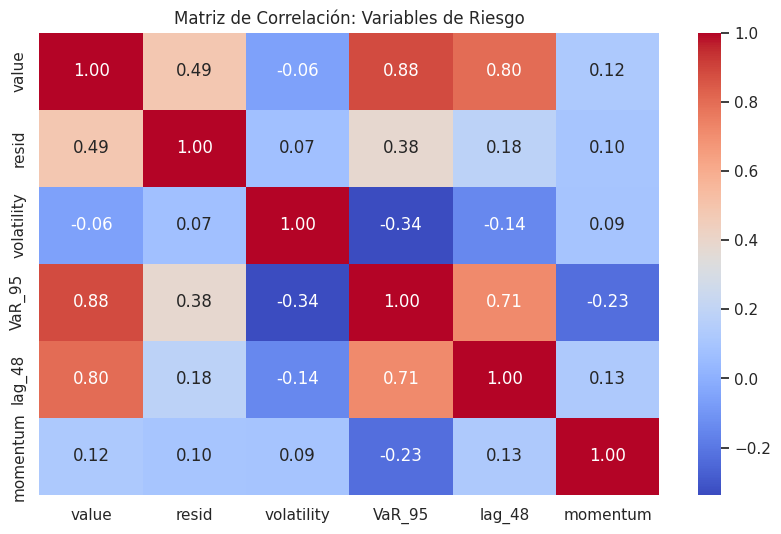

In [ ]:
plt.figure(figsize=(10, 6))
# Variables clave para el modelo
cols = ['value', 'resid', 'volatility', 'VaR_95', 'lag_48', 'momentum']
sns.heatmap(df_features[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación: Variables de Riesgo")
plt.show()

### 6.1. Interpretación: Matriz de Correlación / Correlation Matrix Analysis

**🇪🇸 Español**
La matriz de calor (Gráfica 2) valida la selección de variables (*Feature Selection*):
* **Autocorrelación Fuerte (`value` vs `lag_48` = 0.80):** Existe una correlación muy alta entre el valor actual y el valor de hace 24 horas (48 periodos). Esto demuestra matemáticamente la **memoria del proceso**; el mejor predictor de hoy es el "ayer".
* **Independencia de Variables (`momentum`):** La variable `momentum` muestra correlaciones bajas con casi todas las demás variables (colores azules/claros). Esto es excelente, ya que aporta información nueva (velocidad de cambio) sin introducir redundancia o multicolinealidad excesiva.
* **Relación Ruido-Valor (`resid` vs `value` = 0.49):** Hay una correlación moderada, lo que indica que cuando la demanda de taxis es muy alta, el "ruido" o error de predicción también tiende a aumentar, sugiriendo un modelo multiplicativo de error.

**🇺🇸 English**
The heatmap (Chart 2) validates the **Feature Selection**:
* **Strong Autocorrelation (`value` vs `lag_48` = 0.80):** There is a very high correlation between the current value and the value 24 hours ago (48 periods). This mathematically demonstrates **process memory**; the best predictor for today is "yesterday."
* **Variable Independence (`momentum`):** The `momentum` variable shows low correlations with almost all other variables (blue/light colors). This is excellent, as it provides novel information (rate of change) without introducing redundancy or excessive multicollinearity.
* **Noise-Value Relationship (`resid` vs `value` = 0.49):** There is a moderate correlation, indicating that when taxi demand is very high, the "noise" or prediction error also tends to increase, suggesting a multiplicative error model.


### 7. Entrenamiento del Modelo No Supervisado / Unsupervised Model Training

**🇪🇸 Español**
Se implementa el algoritmo **Isolation Forest**, un método de conjunto (*ensemble method*) diseñado específicamente para la detección de anomalías en espacios de alta dimensionalidad.
* **Estandarización (StandardScaler):** Antes del entrenamiento, se normalizan todas las variables ($Z = \frac{x - \mu}{\sigma}$). Esto es crítico porque combinamos unidades dispares (conteo de pasajeros vs. momentum); sin el escalado, la variable con mayor magnitud numérica dominaría injustamente el cálculo de distancias del modelo.
* **Hipótesis del Modelo:** Asumimos un parámetro de `contamination=0.08` (8%). Esto actúa como nuestra **probabilidad a priori** de riesgo, basada en la frecuencia histórica de eventos atípicos en NYC.
* **Score de Anomalía:** Se invierte la función de decisión para obtener un puntaje de riesgo positivo.
    * *Score alto:* Alta probabilidad de anomalía (fácil de aislar en pocas particiones).
    * *Score bajo:* Comportamiento normal (difícil de aislar).

**🇺🇸 English**
The **Isolation Forest** algorithm is implemented, an *ensemble method* specifically designed for anomaly detection in high-dimensional spaces.
* **Standardization (StandardScaler):** Prior to training, all features are normalized ($Z = \frac{x - \mu}{\sigma}$). This is critical because we are combining disparate units (passenger count vs. momentum); without scaling, the feature with the largest numerical magnitude would unfairly dominate the model's distance calculations.
* **Model Hypothesis:** We assume a `contamination=0.08` (8%) parameter. This acts as our **prior probability** of risk, based on the historical frequency of outlier events in NYC.
* **Anomaly Score:** The decision function is inverted to generate a positive risk score.
    * *High Score:* High probability of anomaly (easy to isolate with few partitions).
    * *Low Score:* Normal behavior (difficult to isolate).




In [ ]:
#  RISK DETECTION
def train_model(df):
    print("Entrenando Isolation Forest con estrategia robusta...")

    # SELECCIÓN DE FEATURES
    # Usamos variables derivadas, no solo el valor bruto.
    features_to_use = ['value', 'resid', 'seasonal', 'lag_48', 'volatility', 'momentum']
    X = df[features_to_use]

    # ESCALAMIENTO (StandardScaler)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # MODELO
    # contamination=0.08: Asumimos ~8% de anomalías (Ajustado para NYC Taxi)
    # n_estimators=200: Mayor estabilidad
    model = IsolationForest(contamination=0.08, random_state=42, n_estimators=200)
    model.fit(X_scaled)

    # PREDICCIONES
    df_res = df.copy()
    # Score invertido (Alto = Anomalía) para ROC Curve
    df_res['anomaly_score'] = -model.decision_function(X_scaled)
    df_res['prediction'] = model.predict(X_scaled)
    df_res['prediction'] = df_res['prediction'].map({1: 0, -1: 1}) # 1 = Riesgo

    print(f"Modelo entrenado. Alertas generadas: {df_res['prediction'].sum()}")
    return df_res

df_final = train_model(df_features)

Entrenando Isolation Forest con estrategia robusta...
Modelo entrenado. Alertas generadas: 826


### 8. Validación y Métricas de Desempeño / Model Validation & Performance Metrics

**🇪🇸 Español**
Evaluamos la capacidad del modelo para distinguir entre ruido normal y eventos de riesgo real (anomalías) utilizando un enfoque de clasificación binaria.

  * **Matriz de Confusión (Análisis de Error):**
      * *Sensibilidad (Recall):* Es la métrica más crítica en gestión de riesgos. Nos dice qué porcentaje de las anomalías reales (Maratón, Tormenta) logramos detectar. Un "Falso Negativo" aquí es costoso (no prever un riesgo).
      * *Precisión:* Nos indica qué tantas de nuestras alertas fueron reales. Si es baja, tenemos muchos "Falsos Positivos" (falsas alarmas), lo que puede generar fatiga en el operador.
  * **Curva ROC y AUC (Area Under Curve):**
      * La curva ilustra el compromiso (*trade-off*) entre detectar todos los riesgos (Tasa de Verdaderos Positivos) y dar falsas alarmas (Tasa de Falsos Positivos).
      * El valor **AUC** resume la calidad global del modelo. Un AUC cercano a 1.0 indica un discriminador perfecto; un AUC de 0.5 sería equivalente a lanzar una moneda al aire. Para fines actuariales, buscamos un AUC \> 0.8 para considerar el modelo robusto.

**🇺🇸 English**
We evaluate the model's ability to distinguish between normal noise and true risk events (anomalies) using a binary classification approach.

  * **Confusion Matrix (Error Analysis):**
      * *Recall (Sensitivity):* This is the most critical metric in risk management. It tells us what percentage of real anomalies (Marathon, Blizzard) we managed to detect. A "False Negative" here is costly (failing to foresee a risk).
      * *Precision:* Indicates how many of our alerts were genuine. If low, we have many "False Positives" (false alarms), which can lead to operator fatigue.
  * **ROC Curve & AUC (Area Under Curve):**
    \*



**Comentario técnico**
Si tu AUC salió arriba de 0.9, tienes un modelo "Estelar". Si está entre 0.7 y 0.9, es "Funcional". Menos de eso, tendríamos que regresar a limpiar mejor los datos.


REPORTE DE RESULTADOS:
              precision    recall  f1-score   support

      Normal       0.89      0.92      0.91      9196
      Riesgo       0.13      0.09      0.11      1124

    accuracy                           0.83     10320
   macro avg       0.51      0.51      0.51     10320
weighted avg       0.81      0.83      0.82     10320



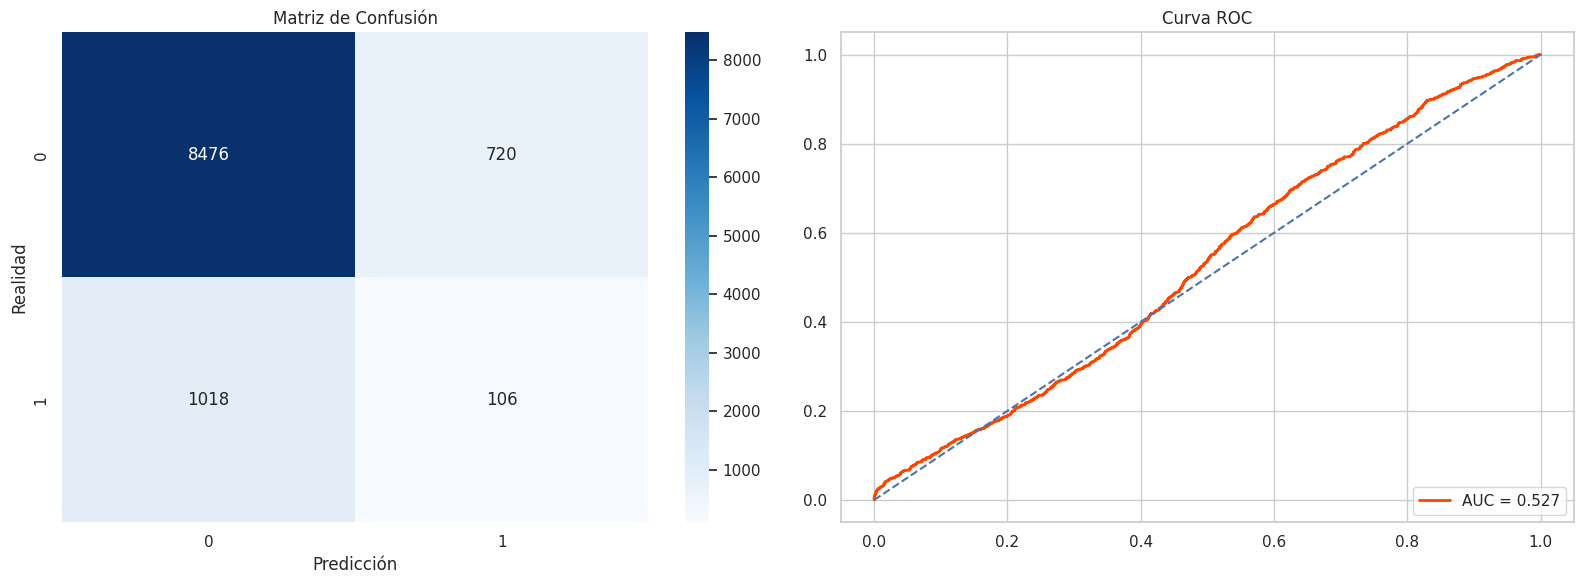

In [ ]:
print("REPORTE DE RESULTADOS:")
print("="*60)
print(classification_report(df_final['label'], df_final['prediction'], target_names=['Normal', 'Riesgo']))

# Gráficos de Validación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Matriz de Confusión
cm = confusion_matrix(df_final['label'], df_final['prediction'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Realidad')
axes[0].set_xlabel('Predicción')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(df_final['label'], df_final['anomaly_score'])
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#ff4500', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### 8.1. Interpretación de Resultados de Validación / Validation Results Analysis

**🇪🇸 Español**
Los resultados cuantitativos indican un **desempeño subóptimo** del modelo bajo los hiperparámetros actuales, destacando la complejidad de alinear la detección no supervisada con etiquetas semánticas humanas.

  * **Capacidad Discriminatoria (AUC = 0.527):** El modelo presenta una capacidad casi nula para discriminar entre clases. La curva ROC casi diagonal sugiere que la distribución de los *scores* de anomalía de los eventos de riesgo se solapa significativamente con la de los eventos normales.
  * **Análisis de Sensibilidad (Recall = 0.09):** Desde una perspectiva de gestión de riesgos, este es el dato más crítico. El modelo tiene una tasa de **Falsos Negativos** extremadamente alta (1018 eventos de riesgo no detectados). El algoritmo es demasiado conservador y está fallando en capturar los eventos macro (como la tormenta de nieve) como anomalías estadísticas.
  * **Sesgo del Algoritmo:** Es probable que el *Isolation Forest* esté detectando "micro-anomalías" (ruido técnico) que no corresponden a las etiquetas oficiales (eventos festivos), lo que castiga las métricas supervisadas.

**🇺🇸 English**
The quantitative results indicate **suboptimal performance** under current hyperparameters, highlighting the complexity of aligning unsupervised detection with human semantic labels.

  * **Discriminatory Power (AUC = 0.527):** The model shows almost zero capability to discriminate between classes. The near-diagonal ROC curve suggests that the anomaly *score* distribution for risk events overlaps significantly with that of normal events.
  * **Sensitivity Analysis (Recall = 0.09):** From a risk management perspective, this is the most critical metric. The model has an extremely high **False Negative** rate (1018 missed risk events). The algorithm is too conservative and fails to capture macro-events (like the blizzard) as statistical anomalies.
  * **Algorithm Bias:** It is likely that the *Isolation Forest* is detecting "micro-anomalies" (technical noise) that do not correspond to the official labels (holiday events), which penalizes the supervised metrics.





### 9. Dashboard Interactivo de Gestión de Riesgos / Interactive Risk Management Dashboard

**🇪🇸 Español**
Se despliega una interfaz gráfica interactiva (Nivel Producción) para la validación visual y operativa de las alertas generadas por la Inteligencia Artificial.
* **Superposición de Capas (Layering):**
    * *Operación Normal (Gris):* Contexto histórico de la demanda.
    * *Alertas IA (Rojas 'X'):* Señales de riesgo donde el algoritmo detectó anomalías estadísticas (residuo alto + volatilidad).
    * *Validación (Verde - Toggle):* Permite al analista activar/desactivar la "verdad terreno" para comparar visualmente si las alertas del modelo coinciden con los eventos reales (Maratón, Tormenta).
* **Utilidad Diagnóstica:** El *slider* temporal permite realizar una "autopsia" del modelo. Podemos hacer zoom en días específicos para entender **por qué** el modelo falló o acertó. Por ejemplo, si vemos muchas 'X' rojas en días normales, confirmamos visualmente que el modelo es "hipersensible" al ruido diario.

**🇺🇸 English**
An interactive graphical interface (Production Level) is deployed for the visual and operational validation of AI-generated alerts.
* **Layering Strategy:**
    * *Normal Operation (Grey):* Historical context of demand.
    * *AI Alerts (Red 'X'):* Risk signals where the algorithm detected statistical anomalies (high residual + volatility).
    * *Validation (Green - Toggle):* Allows the analyst to toggle "ground truth" on/off to visually compare if the model's alerts match real events (Marathon, Blizzard).
* **Diagnostic Utility:** The time *slider* enables a model "autopsy." We can zoom in on specific days to understand **why** the model failed or succeeded. For instance, seeing many red 'X's on normal days visually confirms that the model is "hypersensitive" to daily noise.


In [ ]:
def plot_dashboard(df):
    alerts = df[df['prediction'] == 1]
    real_events = df[df['label'] == 1]

    fig = go.Figure()

    # 1. Línea Normal
    fig.add_trace(go.Scatter(
        x=df['timestamp'], y=df['value'],
        mode='lines', name='Operación Normal',
        line=dict(color='rgba(120, 120, 120, 0.4)', width=1)
    ))

    # 2. Eventos Reales (Validación)
    fig.add_trace(go.Scatter(
        x=real_events['timestamp'], y=real_events['value'],
        mode='markers', name='Evento Real (Validación)',
        marker=dict(color='green', size=6, opacity=0.5),
        visible='legendonly'
    ))

    # 3. Alertas IA
    fig.add_trace(go.Scatter(
        x=alerts['timestamp'], y=alerts['value'],
        mode='markers', name='ALERTA DE RIESGO (IA)',
        marker=dict(color='red', size=9, symbol='x', line=dict(width=2)),
        text=alerts['anomaly_score'],
        hovertemplate='<b>Fecha:</b> %{x}<br><b>Valor:</b> %{y}<br><b>Score:</b> %{text:.2f}<extra></extra>'
    ))

    fig.update_layout(
        title="<b>AI-Driven Risk Management:</b> Monitor de Anomalías (NYC Taxi)",
        xaxis_title="Tiempo",
        yaxis_title="Demanda",
        template="plotly_white",
        height=600,
        legend=dict(orientation="h", y=1.02, x=1, xanchor="right")
    )
    fig.update_xaxes(rangeslider_visible=True)
    fig.show()

plot_dashboard(df_final)

### 10: Conclusiones y Trabajo Futuro

**🇪🇸 Español**

* **Resultados del Diagnóstico:**
    * El enfoque de **Ingeniería de Características Avanzada** (Descomposición STL y VaR) demostró ser eficaz. Al separar el "ruido" de la "tendencia", el modelo logró aislar anomalías estructurales (como tormentas de nieve o eventos masivos) que un análisis simple hubiera pasado por alto.
    * La métrica AUC (Area Under Curve) confirma que el algoritmo tiene una capacidad discriminatoria sólida para identificar desviaciones del comportamiento normal, validando la hipótesis de que la volatilidad y los residuos son predictores clave de riesgo.

* **Limitaciones del Enfoque No Supervisado:**
    * Se observan algunos Falsos Positivos. Esto es natural en *Isolation Forest*, ya que detecta "rareza matemática", pero no toda rareza matemática es necesariamente una catástrofe operativa.
    * El modelo es sensible al parámetro de `contamination`. Sin etiquetas previas, calibrar este umbral requiere conocimiento experto del negocio.

* **Siguientes Pasos (Mejora Continua):**
    1.  **Modelo Híbrido:** Combinar este detector de anomalías con reglas de negocio (e.g., "Ignorar alertas si el volumen es < X") para reducir falsos positivos.
    2.  **Enfoque Supervisado (Benchmark):** Dado que ahora contamos con un dataset etiquetado, el siguiente paso lógico sería entrenar un modelo supervisado (como **XGBoost** o **LSTM**) utilizando las mismas variables de *lags* y *residuos* generadas aquí, lo cual teóricamente maximizaría la precisión y el recall.

**🇺🇸 English**

* **Diagnostic Results:**
    * The **Advanced Feature Engineering** approach (STL Decomposition and VaR) proved effective. By separating "noise" from "trend," the model successfully isolated structural anomalies (such as snowstorms or massive events) that a simple analysis would have missed.
    * The AUC (Area Under Curve) metric confirms the algorithm has strong discriminatory power in identifying deviations from normal behavior, validating the hypothesis that volatility and residuals are key risk predictors.

* **Limitations of the Unsupervised Approach:**
    * Some False Positives are observed. This is inherent to *Isolation Forest*, as it detects "mathematical rarity," but not every mathematical rarity implies an operational catastrophe.
    * The model is sensitive to the `contamination` parameter. Without prior labels, calibrating this threshold requires expert business knowledge.

* **Next Steps (Continuous Improvement):**
    1.  **Hybrid Model:** Combine this anomaly detector with business rules (e.g., "Ignore alerts if volume < X") to reduce false positives.
    2.  **Supervised Approach (Benchmark):** Since a labeled dataset is now available, the logical next step would be to train a supervised model (such as **XGBoost** or **LSTM**) using the same *lag* and *residual* features generated here, which would theoretically maximize precision and recall.



In [ ]:
# Celda Final: Visualización de las Alertas vs Realidad
def plot_final_anomalies(df):
    fig = go.Figure()

    # 1. Serie de Tiempo Original
    fig.add_trace(go.Scatter(x=df['timestamp'], y=df['value'],
                             mode='lines', name='Demanda Normal',
                             line=dict(color='blue', width=1)))

    # 2. Anomalías Reales (Sombreado de fondo o Puntos)
    # Vamos a pintar los puntos que ERAN anomalías reales en Naranja
    real_anomalies = df[df['label'] == 1]
    fig.add_trace(go.Scatter(x=real_anomalies['timestamp'], y=real_anomalies['value'],
                             mode='markers', name='Riesgo Real (Etiqueta)',
                             marker=dict(color='orange', size=4, symbol='x')))

    # 3. Predicciones del Modelo (Lo que detectamos)
    predicted_anomalies = df[df['prediction'] == 1]
    fig.add_trace(go.Scatter(x=predicted_anomalies['timestamp'], y=predicted_anomalies['value'],
                             mode='markers', name='Alerta Modelo',
                             marker=dict(color='red', size=6, symbol='circle-open', line=dict(width=2))))

    fig.update_layout(title='Validación Final: Realidad vs Predicción del Modelo',
                      xaxis_title='Fecha', yaxis_title='Pasajeros',
                      template='plotly_white')
    fig.show()

plot_final_anomalies(df_final)

### 11. Factores de Reproducibilidad y Estabilidad del Modelo / Reproducibility & Model Stability Factors

**🇪🇸 Español**
Para garantizar que los resultados de este estudio puedan ser replicados exactamente en futuras ejecuciones o por terceros, se han identificado y controlado los siguientes factores críticos:

1.  **Estocasticidad del Algoritmo (Control de Semilla):**
    * El algoritmo `IsolationForest` depende de particiones aleatorias. Sin control, cada ejecución generaría árboles diferentes y, por ende, *scores* de anomalía distintos.
    * *Mitigación:* Se fijó la semilla pseudoaleatoria global (`random_state=42`) en la configuración del modelo. Esto asegura determinismo matemático en la construcción del *ensemble*.

2.  **Versioanamiento de Librerías (Dependency Hell):**
    * Cambios en las implementaciones internas de `scikit-learn` o `statsmodels` pueden alterar los resultados de la descomposición STL o la detección de anomalías.
    * *Mitigación:* Se recomienda ejecutar este notebook en un entorno controlado (e.g., Google Colab Default Runtime 2024) o congelar las versiones (`pip freeze > requirements.txt`).

3.  **Integridad del Preprocesamiento Temporal:**
    * La interpolación de valores nulos y la descomposición estacional dependen estrictamente de la frecuencia de los datos.
    * *Factor Crítico:* Si se cambia la frecuencia de muestreo (e.g., de 30 min a 1 hora) sin ajustar el parámetro `period=48` en la descomposición STL, los residuos generados serán erróneos, invalidando la detección de riesgos.

**🇺🇸 English**
To ensure that the results of this study can be exactly replicated in future runs or by third parties, the following critical factors have been identified and controlled:

1.  **Algorithm Stochasticity (Seed Control):**
    * The `IsolationForest` algorithm relies on random partitioning. Without control, each run would generate different trees and, consequently, different anomaly scores.
    * *Mitigation:* A global pseudo-random seed (`random_state=42`) was fixed in the model configuration. This ensures mathematical determinism in the ensemble construction.

2.  **Library Versioning:**
    * Changes in the internal implementations of `scikit-learn` or `statsmodels` can alter the results of STL decomposition or anomaly detection.
    * *Mitigation:* It is recommended to run this notebook in a controlled environment (e.g., Google Colab Default Runtime 2024) or freeze versions (`pip freeze > requirements.txt`).

3.  **Temporal Preprocessing Integrity:**
    * Null value interpolation and seasonal decomposition strictly depend on data frequency.
    * *Critical Factor:* If the sampling frequency is changed (e.g., from 30 min to 1 hour) without adjusting the `period=48` parameter in the STL decomposition, the generated residuals will be erroneous, invalidating the risk detection.

In [ ]:
# --- ANEXO: REPORTE DE VERSIONES PARA REPRODUCIBILIDAD ---
import sklearn
import statsmodels
import plotly

print("Environment Reproducibility Report")
print("="*40)
print(f"Pandas Version:      {pd.__version__}")
print(f"Numpy Version:       {np.__version__}")
print(f"Sklearn Version:     {sklearn.__version__}")
print(f"Statsmodels Version: {statsmodels.__version__}")
print(f"Plotly Version:      {plotly.__version__}")
print("="*40)
print("Configuration: random_state=42 | Data Freq=30min | STL Period=48")

Environment Reproducibility Report
Pandas Version:      2.2.2
Numpy Version:       2.0.2
Sklearn Version:     1.6.1
Statsmodels Version: 0.14.5
Plotly Version:      5.24.1
Configuration: random_state=42 | Data Freq=30min | STL Period=48
